# Turbulent Magnetic field generation

In this notebook, I try to investigate different magnetic field configurations

## 1. Random Magnetic Field: Uniform spectrum

### 1.1. Generate a field

We generate a cube of random magnetic fields (all vector components are distributed according to $~\mathcal{N}(0, \sigma_B)$: $ B = (B_x, B_y, B_z) $

In [222]:
import numpy as np

n = 256
Lx = 100  # [pc] size of the box
Ly = 100 
Lz = 100
x, y, z = np.linspace(-Lx/2, Lx/2, n), np.linspace(-Ly/2, Ly/2, n), np.linspace(-Lz/2, Lz/2, n)  # create a 3D space grid, size 50 pc

xyz = np.array(np.meshgrid(x, y, z)).T.reshape(-1, 3)  # create a 3D grid of points

In [223]:
from scipy.stats import norm, maxwell

B = np.zeros((len(x), len(y), len(z), 3))  # initialize the magnetic field array

# Define the parameters for the Gaussian distribution
mean = np.array([0, 0, 0]) * 1e-6  # [uG] mean of the Gaussian distribution
std_dev = 2e-6  # [uG] standard deviation of the Gaussian distribution

# Generate the magnetic field components using a Gaussian distribution
B[:, :, :, 0] = norm.rvs(loc=mean[0], scale=std_dev, size=(len(x), len(y), len(z)))  # Bx component
B[:, :, :, 1] = norm.rvs(loc=mean[1], scale=std_dev, size=(len(x), len(y), len(z)))  # By component
B[:, :, :, 2] = norm.rvs(loc=mean[2], scale=std_dev, size=(len(x), len(y), len(z)))  # Bz component

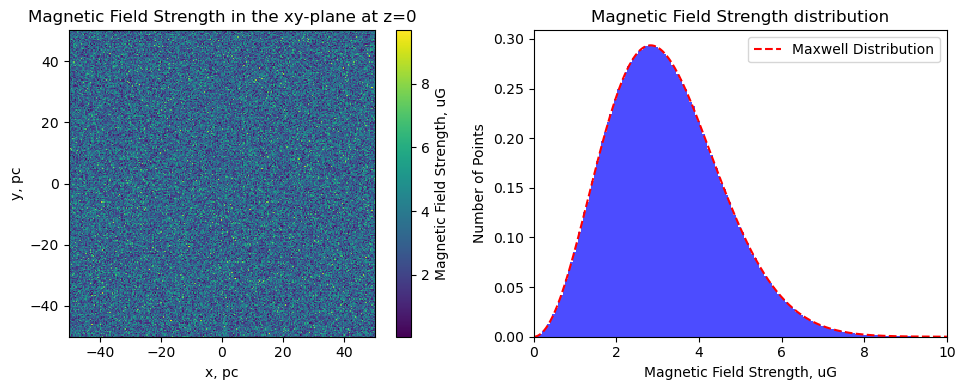

In [261]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))

plt.subplot(121)
plt.title("Magnetic Field Strength in the xy-plane at z=0")

plt.pcolormesh(x, y, np.sqrt(np.sum(B**2, axis=3))[:, :, len(z)//2] * 1e6 ) # plot the Bx component in the xy-plane
plt.colorbar(label='Magnetic Field Strength, uG')

plt.gca().set_aspect('equal', adjustable='box')
plt.xlabel('x, pc')
plt.ylabel('y, pc')

plt.subplot(122)
plt.title("Magnetic Field Strength distribution")

plt.hist(np.sqrt(np.sum(B**2, axis=3)).ravel() * 1e6, bins=200, color='blue', alpha=0.7, density=True)

strength = np.linspace(0, 10, 200) * 1e-6 # [uG] MF strength
plt.plot(strength * 1e6, 1e-6 * maxwell(loc=0, scale=std_dev).pdf(strength),
         color='red', label='Maxwell Distribution', linestyle='dashed')

plt.xlabel('Magnetic Field Strength, uG')
plt.xlim(0, 10)
plt.ylabel('Number of Points')

plt.legend(loc=1)

plt.tight_layout()
plt.show()

### 1.2. Calculate its spectrum

#### Definition

For a magnetic field $\mathbf{B}(\mathbf{r})$ in a volume $V$, the magnetic energy density is $ u_B = \dfrac{\langle B^2 \rangle}{8\pi}, $


#### Fourier Transform Convention

Forward transform:

$$
\mathbf{B}(\mathbf{k}) =
\int d^3r\,
\mathbf{B}(\mathbf{r})
e^{-i\mathbf{k}\cdot\mathbf{r}}.
$$

Inverse transform:

$$
\mathbf{B}(\mathbf{r}) =
\frac{1}{(2\pi)^3}
\int d^3k\,
\mathbf{B}(\mathbf{k})
e^{i\mathbf{k}\cdot\mathbf{r}}.
$$

Parseval's theorem:

$$
\int d^3r\,|\mathbf{B}(\mathbf{r})|^2
=
\frac{1}{(2\pi)^3}
\int d^3k\,|\mathbf{B}(\mathbf{k})|^2.
$$

#### Isotropic 1D Energy Spectrum

The one-dimensional magnetic energy spectrum $E_B(k)$ is defined such that

$$
u_B
=
\int_0^\infty E_B(k)\,dk.
$$

Using the Fourier amplitudes,

$$
E_B(k)
=
\frac{1}{8\pi V(2\pi)^3}
\oint_{|\mathbf{k}|=k}
|\mathbf{B}(\mathbf{k})|^2
\,dS_k.
$$

Equivalently,

$$
E_B(k)
=
\frac{k^2}{2(2\pi)^3V}
\left\langle
|\mathbf{B}(\mathbf{k})|^2
\right\rangle_{\rm ang},
$$

where $\langle\cdots\rangle_{\rm ang}$ denotes the angular average over the sphere $|\mathbf{k}|=k$.


#### Statistical Form

For a homogeneous, isotropic magnetic field,

$$
\left\langle
B_i(\mathbf{k})
B_j^*(\mathbf{k}')
\right\rangle
=
(2\pi)^3
\delta(\mathbf{k}-\mathbf{k}')
\left(
\delta_{ij}
-
\frac{k_i k_j}{k^2}
\right)
P_B(k),
$$

where $P_B(k)$ is the magnetic power spectrum.

The energy spectrum satisfies

$$
E_B(k)\propto k^2P_B(k),
$$

with the proportionality constant depending on the Fourier convention.


#### Practical Computation (Discrete FFT)

For a cubic domain of side length $L$:

- Volume:
  $$
  V=L^3
  $$

- Fundamental wavenumber:
  $$
  \Delta k=\frac{2\pi}{L}
  $$

Procedure:

1. Compute the discrete FFT $\mathbf{B}_{\mathbf{k}}$.
2. Bin Fourier modes into spherical shells.
3. Compute

$$
E_B(k_{\rm bin})
\approx
\frac{1}{8\pi V}
\frac{1}{\Delta k_{\rm bin}}
\sum_{\mathbf{k}\in{\rm shell}}
|\mathbf{B}_{\mathbf{k}}|^2.
$$

The FFT normalization should be chosen so that Parseval's theorem holds.


#### Typical Spectral Slopes

| Turbulence model | Spectrum |
|------------------|----------|
| Kolmogorov | $E_B(k)\propto k^{-5/3}$ |
| Iroshnikov–Kraichnan | $E_B(k)\propto k^{-3/2}$ |
| White noise (equipartition of modes) | $E_B(k)\propto k^2$ |

#### Notes

- Different authors adopt different Fourier normalizations and unit systems.
- Factors of $(2\pi)$ and the overall normalization of $E_B(k)$ therefore vary between references.
- Ensure that the Fourier transform, Parseval's theorem, and the definition of the spectrum are mutually consistent in any implementation.

In [225]:
from scipy.fft import fftn, fftshift, fftfreq

# Fourier transform magnetic field components
B_k = np.zeros((len(x), len(y), len(z), 3), dtype=complex)  # initialize the Fourier transformed magnetic field array
for i in range(3):
    B_k[:, :, :, i] = fftshift(fftn(B[:, :, :, i]))

# get the corresponding frequencies for the FFT
dx = x[1] - x[0]
dy = y[1] - y[0]
dz = z[1] - z[0]

kx = 2*np.pi * fftshift(fftfreq(len(x), d=dx))
ky = 2*np.pi * fftshift(fftfreq(len(y), d=dy))
kz = 2*np.pi * fftshift(fftfreq(len(z), d=dz))

k_xyz = np.array(np.meshgrid(x, y, z)).T.reshape(len(kx), len(ky), len(kz), 3)  # create a 3D grid of points

In [226]:
# obtain spectral energy density of the magnetic field in Fourier space
Bk2 = (np.sum(np.abs(B_k)**2, axis=3))  # sum of the squares of the Fourier transformed components
k = np.sqrt(np.sum(k_xyz**2, axis=3))  # calculate the magnitude of the wavevector

k_flat = k.ravel()
Bk2_flat = Bk2.ravel()

Now we're doing spherical integration. Define spectral bins

In [227]:
dk = min(
    np.abs(kx[1]-kx[0]),
    np.abs(ky[1]-ky[0]),
    np.abs(kz[1]-kz[0]),
)

bins = np.arange(0, k.max() + dk, dk)

To sum over each shell, we use `binned_statistic` function

In [228]:
from scipy.stats import binned_statistic

power, edges, _ = binned_statistic(
    k_flat,
    Bk2_flat,
    statistic="sum",
    bins=bins,
)

k_centers = 0.5 * (edges[:-1] + edges[1:])

In [229]:
V = Lx * Ly * Lz

E = power / (8*np.pi*V*dk)

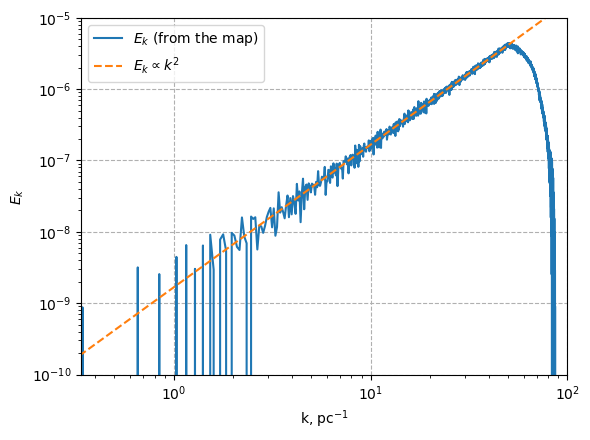

In [257]:
plt.figure(figsize=(6, 4.5))
plt.loglog(k_centers, E, label=r'$E_k$ (from the map)')
plt.loglog(k_centers, k_centers**2 / 6e8, linestyle='dashed', label=r'$E_k\propto k^2$')

plt.xlim(k.min(), 1e2)
plt.xlabel(r'k, $\mathrm{pc}^{-1}$')

plt.ylim(1e-10, 1e-5)
plt.ylabel(r'$E_k$')

plt.legend(loc=2)

plt.grid(linestyle='dashed')

plt.tight_layout()
plt.show()

As expected, for normally distributed magnetic field components, we obtain a $\propto k^2$ power spectrum.